# Chapter 5

## 열림(Open): Erosions -> Dilations

Erosion 을 하면 본체도 깎여 나가는데 이를 복구 할 수 있음

단순히 Erosion 후에 Dilations 하면 됨 = Open

Text(0.5, 1.0, 'Open_cv2')

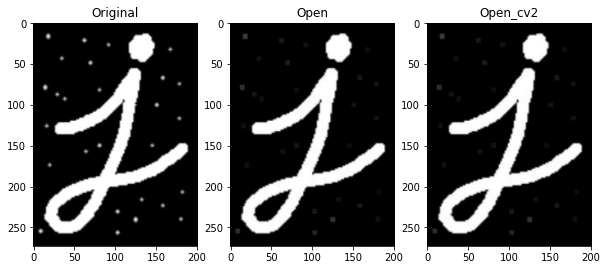

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("Lab/images/morph_dot.jpg", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((3, 3))
k = 2
dst = cv2.erode(src, kernel, iterations=k)
dst = cv2.dilate(dst, kernel, iterations=k)

#----->cv2. open and close는 검정 배경에 흰색을 기본으로 함
# morphologyEx 쓰면 cv2 로도 open, close 가능
dst_cv2 = cv2.morphologyEx(src, cv2.MORPH_OPEN, kernel, iterations=k)


fig, axes = plt.subplots(1,3,figsize=(10, 30))
axes[0].imshow(src, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(dst, cmap='gray')
axes[1].set_title('Open')


axes[2].imshow(dst_cv2, cmap='gray')
axes[2].set_title('Open_cv2')


## 닫힘(Close): Dilations -> Erosions

Dilations 하면 본체가 불어나는데 이를 방지
<br> Dilations -> Erosions  = Close

Text(0.5, 1.0, 'Close_cv2')

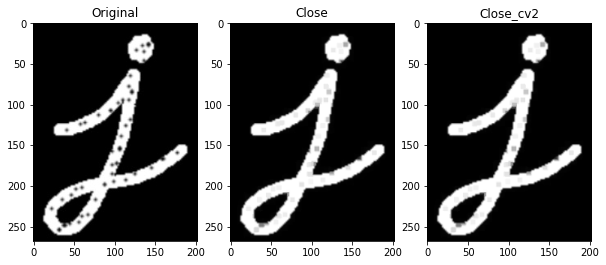

In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("Lab/images/morph_hole.jpg", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((3, 3), np.uint8)

dst = cv2.dilate(src, kernel, iterations=k)
dst = cv2.erode(dst, kernel, iterations=k)

dst_cv2 = cv2.morphologyEx(src, cv2.MORPH_CLOSE, kernel, iterations=k)


fig, axes = plt.subplots(1,3,figsize=(10, 30))

axes[0].imshow(src, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(dst, cmap='gray')
axes[1].set_title('Close')


axes[2].imshow(dst_cv2, cmap='gray')
axes[2].set_title('Close_cv2')


### 여기부턴 시험범위 안들어감

## Gradient = Dilation (max) - Erode (min)


Text(0.5, 1.0, 'Gradient_cv2')

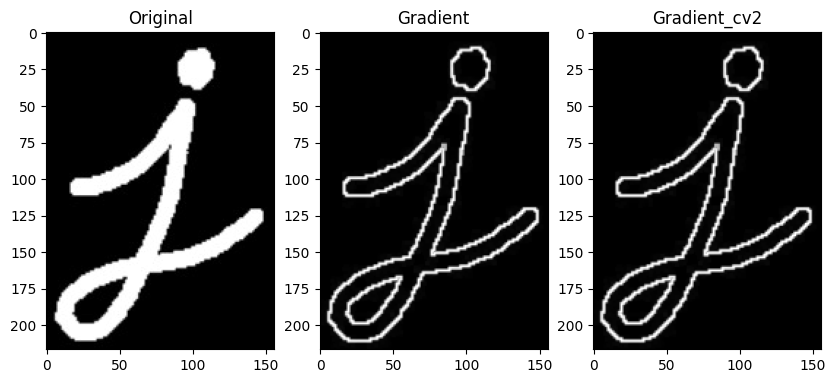

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("images/morph.jpg", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((3, 3), np.uint8)
k = 1
dst = cv2.dilate(src, kernel, iterations=k) - cv2.erode(src, kernel, iterations=k)
dst_cv2 = cv2.morphologyEx(src, cv2.MORPH_GRADIENT, kernel, iterations=k)


fig, axes = plt.subplots(1,3,figsize=(10, 30))

axes[0].imshow(src, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(dst, cmap='gray')
axes[1].set_title('Gradient')


axes[2].imshow(dst_cv2, cmap='gray')
axes[2].set_title('Gradient_cv2')


## Tophat = Source - Open = I - Dilation(Erosion(I))

- **`Highlights parts of the image that were removed by the opening`** — often small bright features, noise, or details.

- `Used to reveal bright regions of an image on dark backgrounds`




주변보다 밝은 미세 영역 추출
<br> 자동차 번호판 추출에 주로 씀

Text(0.5, 1.0, 'Tophat_cv2')

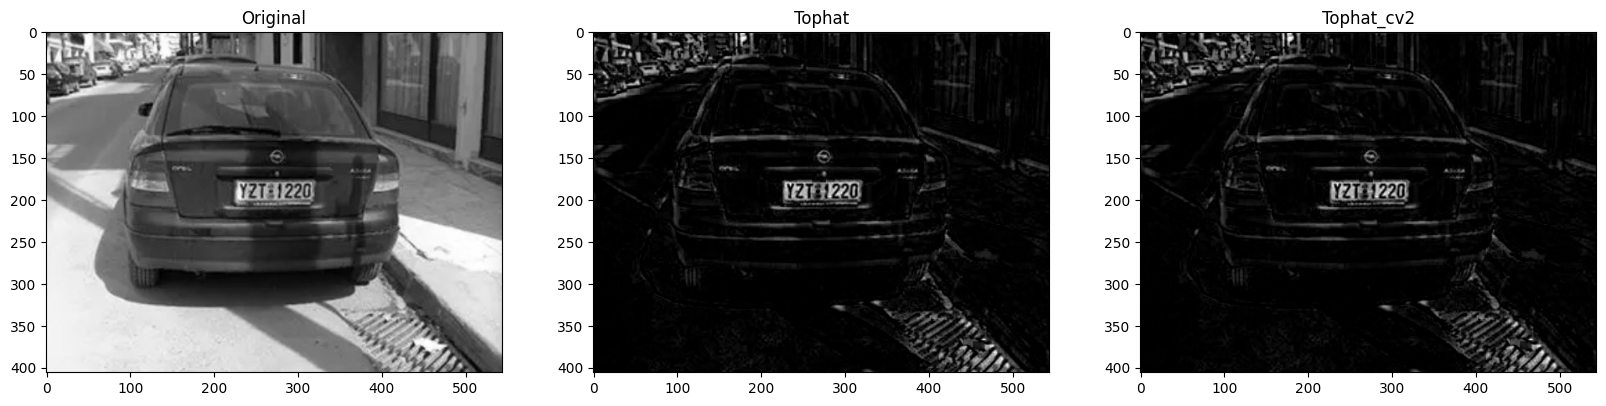

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("Lab/images/morph_car.jpg", cv2.IMREAD_GRAYSCALE)

# kernel = np.ones((3, 3), np.uint8)
kernel = np.ones((9, 9), np.uint8)
k = 1

dst = src - cv2.morphologyEx(src, cv2.MORPH_OPEN, kernel, iterations=k)
dst_cv2 = cv2.morphologyEx(src, cv2.MORPH_TOPHAT, kernel, iterations=k)


fig, axes = plt.subplots(1,3,figsize=(20, 60))

axes[0].imshow(src, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(dst, cmap='gray')
axes[1].set_title('Tophat')


axes[2].imshow(dst_cv2, cmap='gray')
axes[2].set_title('Tophat_cv2')


#### Tophat + Close:
- Can detect the area of plate

Text(0.5, 1.0, 'Tophat+Close')

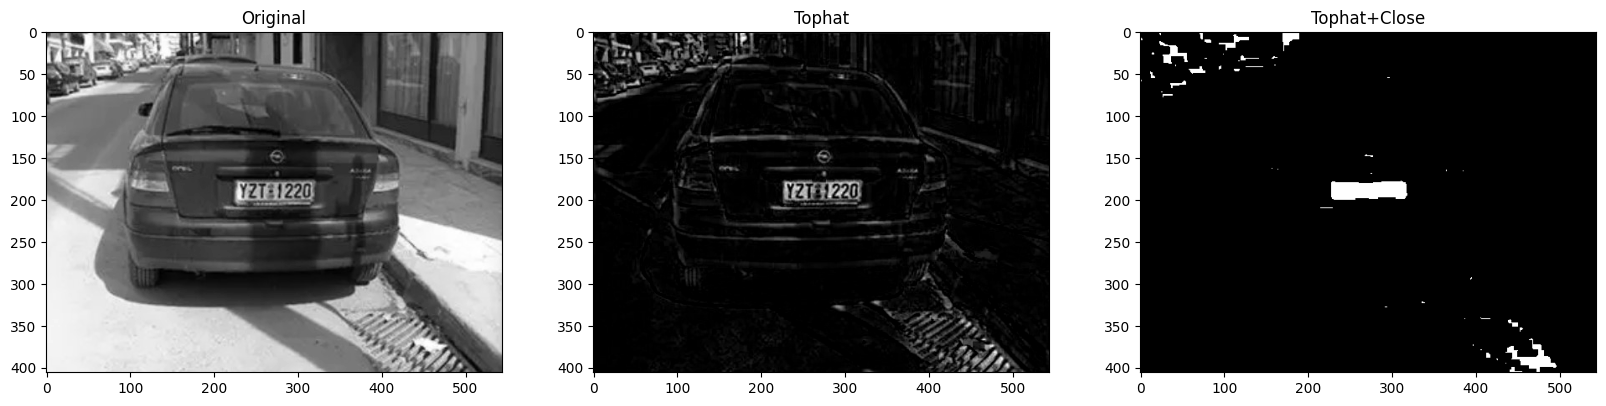

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("Lab/images/morph_car.jpg", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((9, 9), np.uint8)
k = 1
dst_top = cv2.morphologyEx(src, cv2.MORPH_TOPHAT, kernel, iterations=k)

kernel = np.ones((7, 15), np.uint8)
dst = cv2.morphologyEx(dst_top, cv2.MORPH_CLOSE, kernel, iterations=k)
_, dst = cv2.threshold(dst, 100, 255, cv2.THRESH_BINARY)


fig, axes = plt.subplots(1,3,figsize=(20, 60))

axes[0].imshow(src, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(dst_top, cmap='gray')
axes[1].set_title('Tophat')

axes[2].imshow(dst, cmap='gray')
axes[2].set_title('Tophat+Close')




## Blackhat = Close - Source = Erosion(Dilation(I)) - I

- **`Shows what was added to the original image to close it`**

    - Dark features against a bright background that were filled in by the closing operation

    - `Shadows, small cracks, or dark text on light backgrounds`


Text(0.5, 1.0, 'Blackhat_cv2')

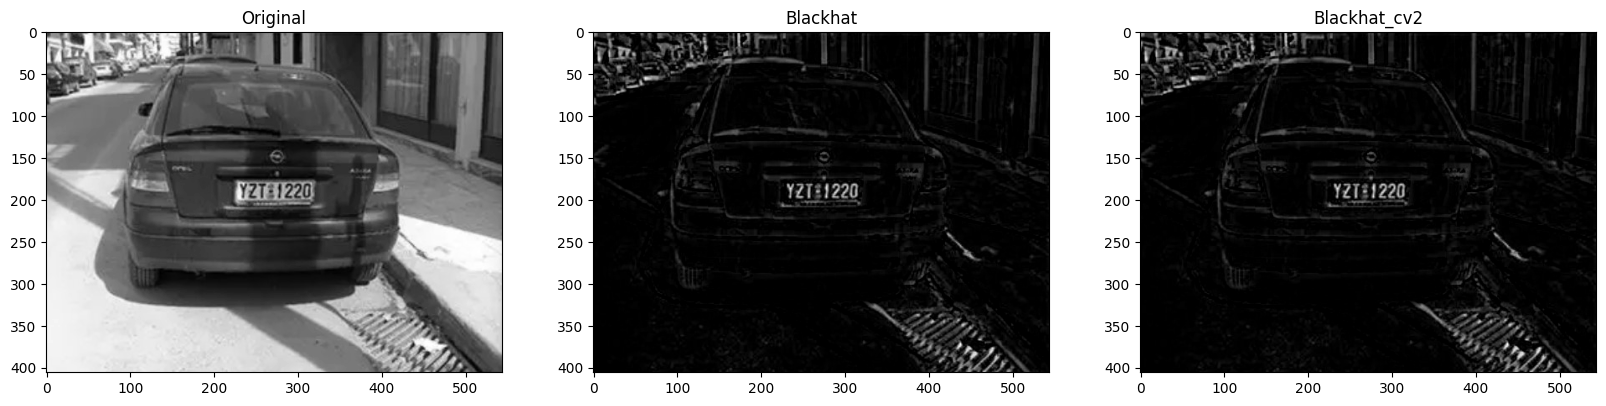

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src = cv2.imread("images/morph_car.jpg", cv2.IMREAD_GRAYSCALE)

kernel = np.ones((9, 9), np.uint8)
k = 1

dst = cv2.morphologyEx(src, cv2.MORPH_CLOSE, kernel, iterations=k) - src
dst_cv2 = cv2.morphologyEx(src, cv2.MORPH_BLACKHAT, kernel, iterations=k)


fig, axes = plt.subplots(1,3,figsize=(20, 60))

axes[0].imshow(src, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(dst, cmap='gray')
axes[1].set_title('Blackhat')


axes[2].imshow(dst_cv2, cmap='gray')
axes[2].set_title('Blackhat_cv2')
